#Projekat 1 - nadgledano ucenje


## Sadrzaj:
* [Ucitavanje podataka](#data_loading)
* [Priprema podataka](#data_cleaning)
  * [Obrada nedostajucih vrednosti](#missing_values)
   * [Obrada duplikata](#duplicate_values)
   * [Ekstremne vrednosti](#outlier_values)
   * [Enkodiranje](#encoding)
   

In [20]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

***

##Ucitavanje podataka <a name="data_loading" class="anchor" id="data_loading"></a>

Ucitavamo dataset [Greenhouse Plant Growth Metrics](https://www.kaggle.com/datasets/adilshamim8/greenhouse-plant-growth-metrics/data)

In [2]:
dataframe=pd.read_csv('Greenhouse_Plant_Growth_Metrics.csv')
dataframe.head()

,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA


In [3]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Random  30000 non-null  object 
 1   ACHP    30000 non-null  float64
 2   PHR     30000 non-null  float64
 3   AWWGV   30000 non-null  float64
 4   ALAP    30000 non-null  float64
 5   ANPL    30000 non-null  float64
 6   ARD     30000 non-null  float64
 7   ADWR    30000 non-null  float64
 8   PDMVG   30000 non-null  float64
 9   ARL     30000 non-null  float64
 10  AWWR    30000 non-null  float64
 11  ADWV    30000 non-null  float64
 12  PDMRG   30000 non-null  float64
 13  Class   30000 non-null  object 
dtypes: float64(12), object(2)
memory usage: 3.2+ MB


Dataset sadrzi 30000 redova i 14 atributa.<br><br>
Opis atributa skupa podataka:<br>

Random - Identifikator koji označava različite serije (batch-eve) biljnih uzoraka (npr. R1, R2, R3).<br>

ACHP - Prosečan sadržaj hlorofila po biljci, koji predstavlja indikator fotosintetske aktivnosti.<br>

PHR - Brzina rasta visine biljke, koja meri vertikalni rast biljke tokom vremena.<br>

AWWGV - Prosečna sveža (vlažna) masa vegetativnog rasta, odnosno ukupna masa nadzemnih delova biljke.<br>

ALAP - Prosečna površina listova po biljci, koja utiče na intenzitet fotosinteze.<br>

ANPL - Prosečan broj listova po biljci, koji ukazuje na stepen razvijenosti i gustinu lisne mase.<br>

ARD - Prosečan prečnik korena, relevantan za efikasnost usvajanja vode i hranljivih materija.<br>

ADWR - Prosečna suva masa korena, koja predstavlja ukupnu biomasu korenskog sistema nakon sušenja.<br>

PDMVG - Procenat suve materije u vegetativnom rastu, koji meri udeo čvrste materije u nadzemnim delovima biljke.<br>

ARL - Prosečna dužina korena, koja ukazuje na razvijenost i dubinu korenskog sistema.<br>

AWWR - Prosečna sveža (vlažna) masa korena, odnosno ukupna masa korena pre sušenja.<br>

ADWV - Prosečna suva masa vegetativnih delova biljke, odnosno biomasa nadzemnih delova nakon sušenja.<br>

PDMRG - Procenat suve materije u rastu korena, koji predstavlja udeo čvrste materije u korenskom sistemu.<br>

Class - Kategorička oznaka eksperimentalne grupe:<br>
SA, SB, SC – tradicionalni tip plastenika,<br>
TA, TB, TC – plastenik zasnovan na IoT tehnologiji.<br>

Ove skraćenice su teške za praćenje, zbog toga u sledećem koraku menjam nazive atributa da budu čitljiviji.

In [4]:
rename_dict = {
    'Random':'random',
    'ACHP': 'avg_chlorophyll',
    'PHR': 'plant_height_growth_rate',
    'AWWGV': 'avg_wet_weight_vegetative',
    'ALAP': 'avg_leaf_area',
    'ANPL': 'avg_num_leaves',
    'ARD': 'avg_root_diameter',
    'ADWR': 'avg_dry_weight_roots',
    'PDMVG': 'pct_dry_matter_vegetative',
    'ARL': 'avg_root_length',
    'AWWR': 'avg_wet_weight_roots',
    'ADWV': 'avg_dry_weight_vegetative',
    'PDMRG': 'pct_dry_matter_roots',
    'Class': 'class'
}
dataframe = dataframe.rename(columns=rename_dict)
dataframe.head()


,random,avg_chlorophyll,plant_height_growth_rate,avg_wet_weight_vegetative,avg_leaf_area,avg_num_leaves,avg_root_diameter,avg_dry_weight_roots,pct_dry_matter_vegetative,avg_root_length,avg_wet_weight_roots,avg_dry_weight_vegetative,pct_dry_matter_roots,class
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA


***

##Priprema podataka<a class="anchor" id="data_cleaning" name ="data_cleaning"></a>

###Obrada nedostajucih vrednosti <a class="anchor" id="missing_values" name ="missing_values"></a>

U ovom koraku najpre proveravamo da li u skupu podataka ima nedostajucih vrednosti. Ovu proveru vršimo sa metodom isnull(), koja vraća True za vrednosti None ili NaN. Suma ove provere po koloni će biti različita od nule ako u koloni postoje nedostajuće vrednosti.<br> Ova provera nad datasetom prikazuje da u ovom datasetu nema nedostajućih vrednosti.

In [5]:
dataframe.isnull().sum()

,0
random,0
avg_chlorophyll,0
plant_height_growth_rate,0
avg_wet_weight_vegetative,0
avg_leaf_area,0
avg_num_leaves,0
avg_root_diameter,0
avg_dry_weight_roots,0
pct_dry_matter_vegetative,0
avg_root_length,0


###Provera duplikata<a class="anchor" id="duplicate_values" name ="duplicate_values"></a>

U ovom datasetu ne postoji jedinstveni identifikator po kom bi trebala da se vrši provera duplikata. Iskoristićemo funkciju duplicated koja za svaki red vraća True ukoliko sadrži potpuno iste vrednosti kao neki drugi red. U ovom slučaju, takvih redova nema.

In [6]:
dataframe.duplicated().sum()

np.int64(0)

###Ekstremne vrednosti<a class="anchor" id="outlier_values" name ="outlier_values"></a>

U ovom koraku je potrebno za sve numericke kolone identifikovati ekstremne vrednosti i obraditi ih

In [16]:
num_cols = dataframe.select_dtypes(include=['float']).columns #indeksi svih numerickih kolona

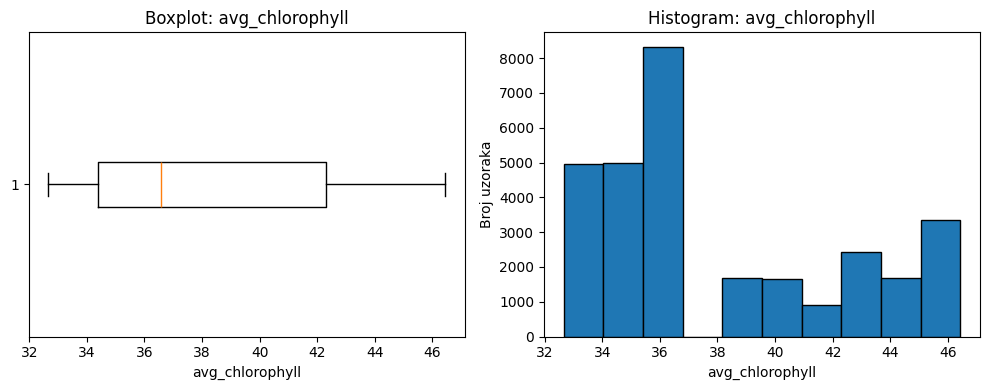

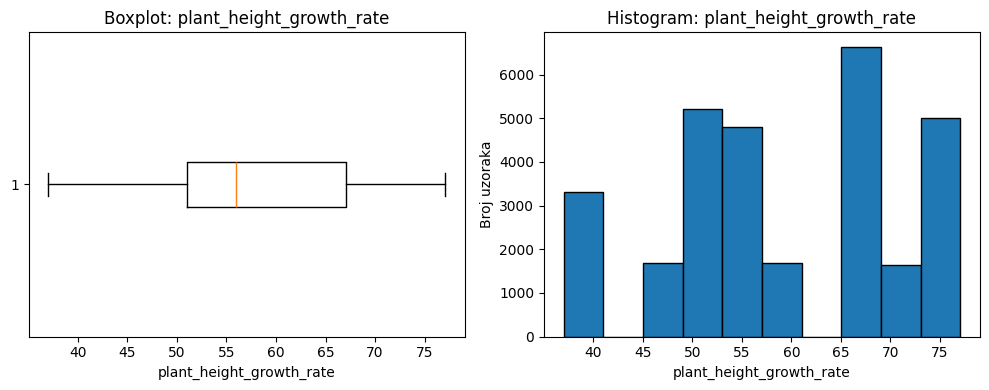

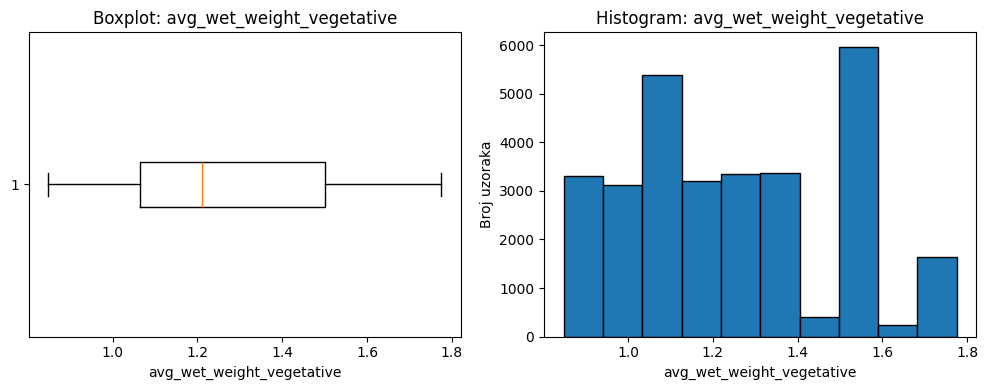

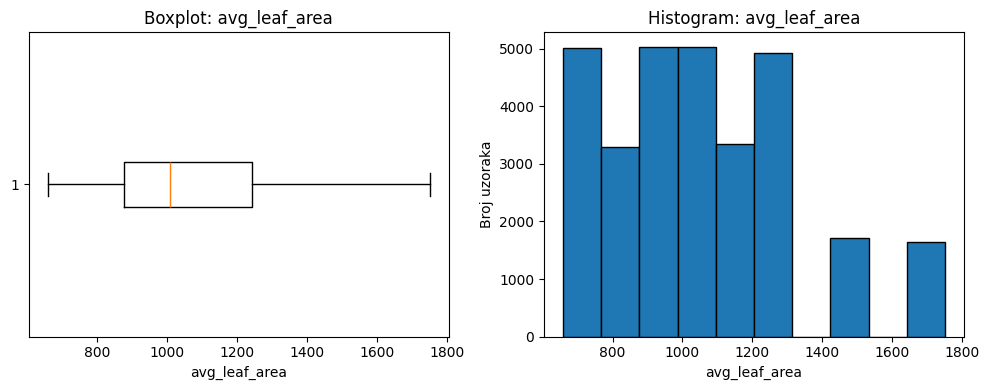

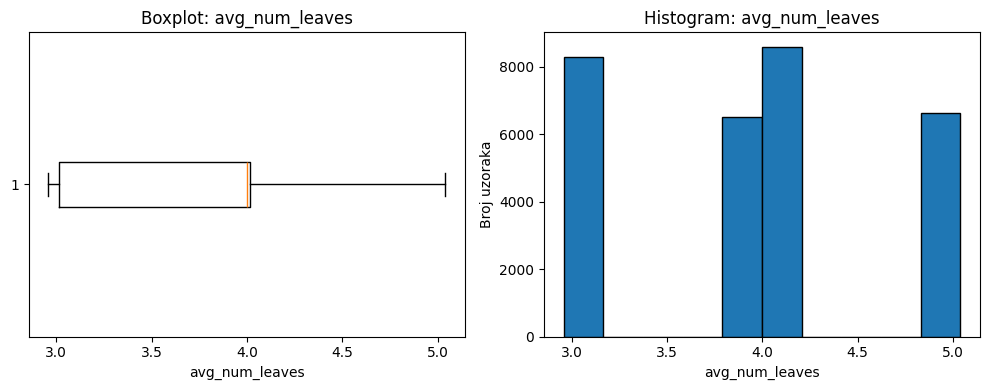

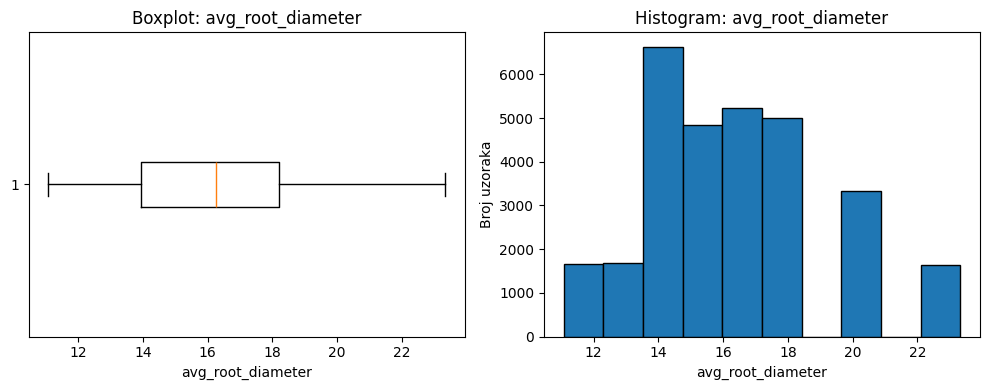

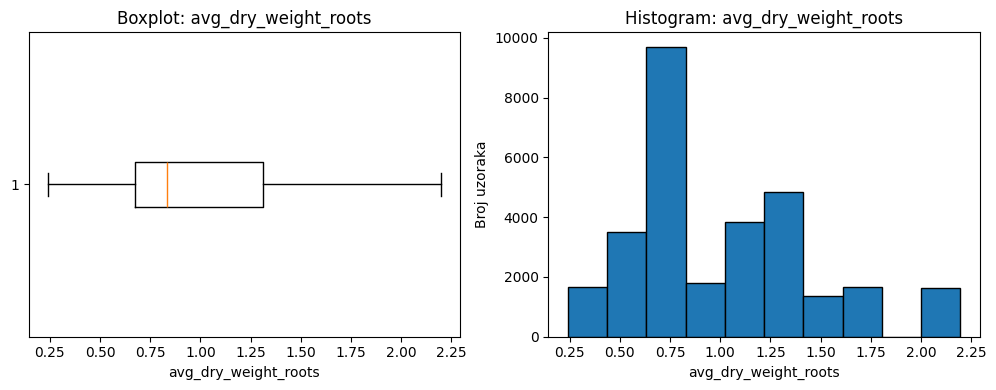

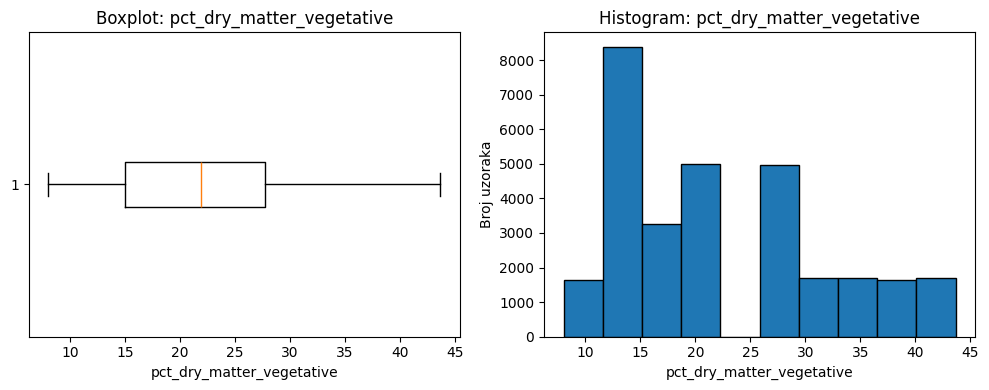

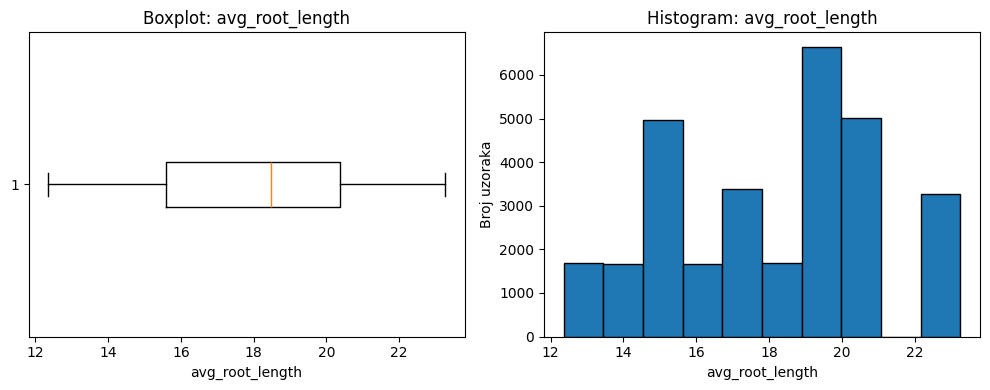

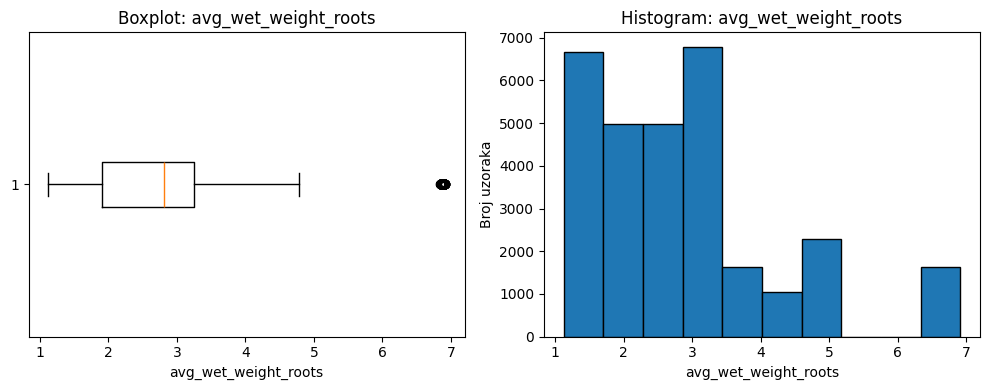

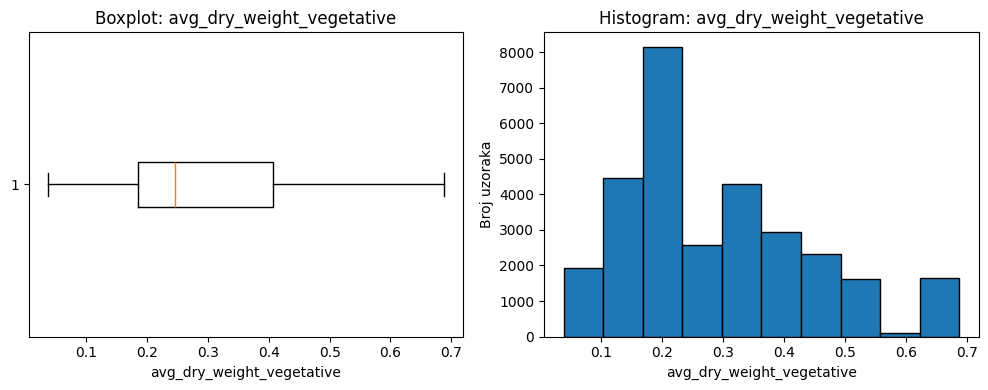

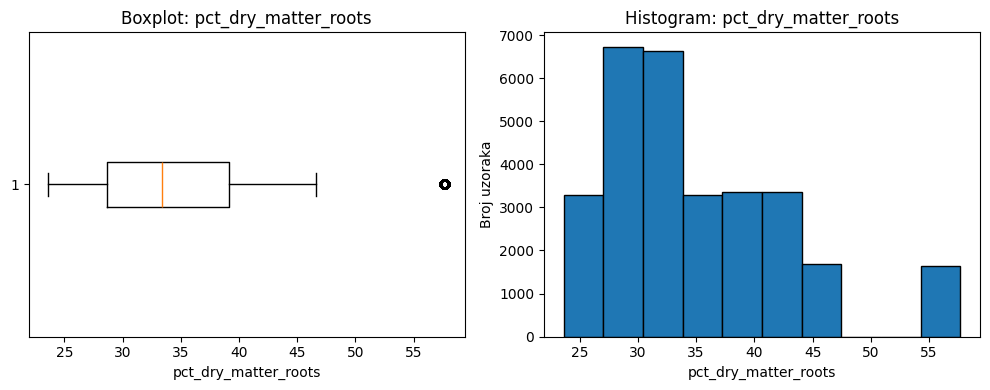

In [26]:
for col in num_cols:
  plt.figure(figsize=(10,4))

  # Boxplot
  plt.subplot(1, 2, 1)
  plt.boxplot(dataframe[col], vert=False)
  plt.title(f'Boxplot: {col}')
  plt.xlabel(col)

  # Histogram
  plt.subplot(1, 2, 2)
  plt.hist(dataframe[col], bins=10, edgecolor='black')
  plt.title(f'Histogram: {col}')
  plt.xlabel(col)
  plt.ylabel('Broj uzoraka')

  plt.tight_layout()
  plt.show()

In [17]:
z_scores = np.abs(stats.zscore(dataframe[num_cols]))
outlier_rows = np.where(z_scores > 3)

print(outlier_rows)


(array([], dtype=int64), array([], dtype=int64))


In [14]:
for col in num_cols:
  Q1 = dataframe[col].quantile(0.25)
  Q3 = dataframe[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outliers = dataframe[(dataframe[col] < lower_bound) | (dataframe[col] > upper_bound)]
  print(f'{col} outliers:', len(outliers))



avg_chlorophyll outliers: 0
plant_height_growth_rate outliers: 0
avg_wet_weight_vegetative outliers: 0
avg_leaf_area outliers: 0
avg_num_leaves outliers: 0
avg_root_diameter outliers: 0
avg_dry_weight_roots outliers: 0
pct_dry_matter_vegetative outliers: 0
avg_root_length outliers: 0
avg_wet_weight_roots outliers: 1627
avg_dry_weight_vegetative outliers: 0
pct_dry_matter_roots outliers: 1646


###Enkodiranje<a class="anchor" id="encoding" name ="encoding"></a>

Postoje dva kategorička atributa u ovom datasetu. To su kolone 'random' i 'class'. <br><br> Ispod je prikazan pregled vrednosti u koloni 'class'. Imamo 6 jedinstvenih vrednosti u ovoj koloni, kao što je i navedeno u dokumentaciji za dataset - SA, SB, SC, TA, TB, TC.

In [ ]:
dataframe['class'].value_counts()

,count
class,
SA,5000
SB,5000
SC,5000
TA,5000
TB,5000
TC,5000


Ove kategorije su po svojoj prirodi nominalne, odnosno između njih ne postoji uređenje. Međutim, kako je za klasifikaciju ovaj atribut ciljni, nema smisla iskoristiti one-hot enkodiranje. Zbog toga ćemo iskoristiti jednostavno enkodiranje po labeli.

In [ ]:
le = LabelEncoder()
dataframe['Class_encoded'] = le.fit_transform(dataframe['Class'])

dataframe.head()

,Random,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class,Class_encoded
0,R1,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,SA,0
1,R1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,SA,0
2,R2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,SA,0
3,R1,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,SA,0
4,R3,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,SA,0


In [ ]:
dataframe['random'].value_counts()

,count
random,
R1,10045
R3,9996
R2,9959


In [ ]:
dataframe=dataframe.drop(columns=["Random","Class"])
dataframe.head()

,ACHP,PHR,AWWGV,ALAP,ANPL,ARD,ADWR,PDMVG,ARL,AWWR,ADWV,PDMRG,Class_encoded
0,34.533468,54.566983,1.147449,1284.229549,4.999713,16.274918,1.706810,18.399982,19.739037,2.949240,0.209251,57.633906,0
1,34.489028,54.567692,1.149530,1284.247744,5.024259,16.269452,1.700930,18.398289,19.758836,2.943137,0.216154,57.633697,0
2,33.100405,67.067344,1.104647,1009.208996,5.007652,15.980760,1.185391,19.398789,20.840822,2.861635,0.200113,41.289875,0
3,34.498319,54.559049,1.137759,1284.227623,4.991501,16.276710,1.716396,18.413613,19.736098,2.946784,0.223092,57.645661,0
4,36.297008,45.588894,1.363205,981.470310,4.003682,16.979894,0.777428,31.423772,17.331894,2.766242,0.424172,27.898619,0
